# 2. My dataset

In notebook 01 you measured Whisper on LibriSpeech: other people reading audiobooks. Fine-tuning needs examples of exactly what you want the model to get better at, which is **your voice saying your words**. In this notebook you build that dataset, check it, split it, and measure how well Whisper does on it before any training. That last number is the **baseline**, the score fine-tuning has to beat.

1. **Part 1, the sentence list.** Personalize the ~200 sentences you'll read aloud.
2. **Part 2, recording.** Record them with a small terminal program, `record.py`.
3. **Part 3, checking.** Write code that catches bad recordings: too quiet, clipped, too long.
4. **Part 4, splitting.** Divide the sentences into training, validation, and test sets.
5. **Part 5, the baseline.** Transcribe your test sentences with whisper-tiny.en and whisper-base.en, and compute WER overall, WER per category, and how often your key terms come out right.
6. **Part 6.** Move your functions into a shared file so notebooks 03 and 04 can use them.

Cells marked **TODO(you)** are yours. Each one comes after an explanation of the idea, the types of data involved, and every function you'll need, and most are followed by a check cell that tells you whether your code works.

## The files this notebook uses

| file | what it holds | who writes it |
|---|---|---|
| `data/sentences.csv` | the sentences to read, one per row | drafted for you; you personalize it in Part 1 |
| `data/vocabulary.txt` | your key terms (names, tools, jargon), one per line | same |
| `record.py` | the recording program | provided |
| `data/recordings/*.wav` | your audio, one file per recording | `record.py` |
| `data/metadata.csv` | one row per recording: file name, sentence, transcript, length | `record.py` |
| `data/splits.json` | which sentences are training, validation, and test | you, in Part 4 |
| `results/baseline.json` | the baseline scores | you, in Part 5 |
| `whisper_ft.py` | helper functions shared by notebooks 02 to 04 | provided; you add your own functions in Part 6 |

`data/recordings/` is listed in `.gitignore`, so your voice never goes to the public GitHub repo. The sentence list does, so only use names you're comfortable publishing.

## The data types you'll meet

Every value in Python has a **type**, and most bugs in data code come from having a different type than you think: a string where you expected a number, or a list where you expected one item. When in doubt, print `type(x)`, and for arrays also `x.shape` and `x.dtype`.

| type | what it is | example in this notebook | how to look inside |
|---|---|---|---|
| `str` | text | `"Move the model to the GPU."` | `len(s)`, `s.lower()`, `s.split()` |
| `int`, `float` | whole and decimal numbers | `16000`, `3.27` | |
| `bool` | `True` or `False` | `contains_term(text, "LoRA")` | |
| `list` | an ordered sequence you can change; items are numbered from 0 | `["s001", "s002"]` | `len(x)`, `x[0]`, `x[-1]`, `x[:5]` |
| `tuple` | an ordered sequence you can't change; functions use it to return several values at once | `(audio, 16000)` | `a, b = t` unpacks it into two variables |
| `dict` | a lookup table from keys to values | `{"sentence_id": "s001", "text": "..."}` | `d["text"]`, `d.keys()`, `d.items()` |
| `set` | an unordered collection without duplicates; checking membership is fast | `{"s001", "s007"}` | `"s001" in ids` |
| `np.ndarray` | a NumPy array: a grid of numbers that all share one dtype | a waveform | `x.shape`, `x.dtype`, `x.ndim` |
| `torch.Tensor` | PyTorch's array; works like a NumPy array, and can also track gradients | input features for the model | `t.shape`, `t.dtype` |

Two patterns come up constantly:

- **A list of dicts** is how this project stores tables. Each dict is one row, and each key is a column, so `rows[0]["text"]` is the transcript of the first recording.
- **A list comprehension** builds a list from another one: `[row["text"] for row in rows]` means "for each row, take its text". Add a condition to filter: `[row for row in rows if row["category"] == "ml"]`.

## Setup

- `%load_ext autoreload` and `%autoreload 2` make the notebook reload `whisper_ft.py` whenever you change it, so you don't need to restart the kernel after editing that file.
- `from whisper_ft import ...` pulls functions and values out of `whisper_ft.py`. Open it and read the top half; every function there is short and has a description. `processor` is the same `WhisperProcessor` you used in notebook 01, and `SAMPLE_RATE` is `16000`.
- `from IPython.display import Audio as Play` imports the audio player under a different name, so it doesn't clash with anything else called `Audio`.
- `set_verbosity_error()` and `disable_progress_bar()` hide the transformers library's warnings and its "Loading weights" progress bars.

In [1]:
%load_ext autoreload
%autoreload 2

import random
import tempfile
from collections import Counter
from pathlib import Path

import jiwer
import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf
import sounddevice as sd
import torch
import transformers
from IPython.display import Audio as Play
from IPython.display import display
from transformers import WhisperForConditionalGeneration

from whisper_ft import (
    DATA_DIR,
    RESULTS_DIR,
    SAMPLE_RATE,
    contains_term,
    load_librispeech,
    load_metadata,
    load_sentences,
    load_vocabulary,
    processor,
    read_wav,
    save_json,
)

transformers.logging.set_verbosity_error()
transformers.logging.disable_progress_bar()
print("Data folder:", DATA_DIR)

c:\Users\praja\Desktop\yp\Whisper\whisper-finetune\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data folder: C:\Users\praja\Desktop\yp\Whisper\whisper-finetune\data


## Part 1: the sentence list

### What makes a good sentence list

The model learns from exactly what you give it, so the sentences decide what fine-tuning can fix. The draft in `data/sentences.csv` follows six rules:

1. **Say what you actually say.** The sentences are written like dictation: messages, notes, and the ML and tool talk from this project.
2. **Natural casing and punctuation.** A fine-tuned model copies the style of its transcripts, so write each sentence exactly as you'd want your dictation to appear.
3. **Repeat each key term in several different sentences.** Every term in `data/vocabulary.txt` appears in at least three sentences. After the split in Part 4, a term usually lands in some training sentences *and* some test sentences, so the test measures whether the model learned the word, not whether it memorized one sentence.
4. **Keep each sentence well under 30 seconds.** Whisper only hears 30 seconds at a time. These sentences take 2 to 6 seconds to say.
5. **Mix in everyday speech.** About a fifth of the sentences have no jargon. They show whether fine-tuning made the model worse at normal speech, and they keep it from hearing jargon everywhere.
6. **Write numbers and names the way you want them typed**, because that's what the model will learn to output.

Each sentence has a **category**: `everyday`, `tools`, `ml`, or `names`. In Part 5 you'll use the categories to see where Whisper struggles.

### Look at the draft

- `load_sentences()` reads `data/sentences.csv` and returns a **list of dicts**, one dict per row, with the keys `sentence_id`, `category`, and `text`. Every value is a `str`, because a CSV file is plain text.
- `load_vocabulary()` returns a **list of str**, one term per line of `data/vocabulary.txt`.
- `Counter(...)` (from Python's `collections` module) counts how often each value appears. It returns a dict-like object that maps each value to its count.

In [2]:
sentences = load_sentences()
vocabulary = load_vocabulary()

print(type(sentences).__name__, "of", len(sentences), "sentences")
print("One sentence:", type(sentences[0]).__name__, sentences[0])
print()
print("Sentences per category:", dict(Counter(s["category"] for s in sentences)))
print(len(vocabulary), "vocabulary terms, for example:", vocabulary[:8])

list of 209 sentences
One sentence: dict {'sentence_id': 's001', 'category': 'ml', 'text': 'Move the model to the GPU before training.'}

Sentences per category: {'ml': 89, 'everyday': 45, 'names': 26, 'tools': 49}
63 vocabulary terms, for example: ['Cursor', 'GitHub', 'PyTorch', 'Hugging Face', 'Colab', 'Kaggle', 'Jupyter', 'NumPy']


### TODO(you): make the list yours

Open `data/sentences.csv` and `data/vocabulary.txt` in Cursor.

1. **Replace the placeholders.** Some sentences contain `{PERSON_1}` to `{PERSON_4}`, `{PLACE_1}`, and `{PLACE_2}`. Pick real names you say often: friends, teammates, family, your city, your school. Replace each placeholder everywhere in **both** files. Cursor's search and replace across files (`Ctrl+Shift+H`) does it in one step. The repo is public, so choose names you're happy to publish.
2. **Edit anything that doesn't sound like you.** Reword sentences, delete ones you'd never say, and add your own. Keep every `sentence_id` unique (number new ones `s210`, `s211`, and so on), and use one of the four categories.
3. **Add terms you actually use** to `data/vocabulary.txt`, and make sure each one appears in at least two sentences (three is better).
4. **Read a few sentences out loud.** Change anything you stumble on.

Save both files, then run the next cell. It reloads the files and checks them.

In [3]:
sentences = load_sentences()
vocabulary = load_vocabulary()

ids = [s["sentence_id"] for s in sentences]
assert len(ids) == len(set(ids)), "two sentences share a sentence_id"
assert all(s["category"] in {"everyday", "tools", "ml", "names"} for s in sentences), "a sentence has an unknown category"
assert all(s["text"].strip() for s in sentences), "a sentence is empty"
leftover = [s["sentence_id"] for s in sentences if "{" in s["text"]] + [t for t in vocabulary if "{" in t]
assert not leftover, f"placeholders left to replace: {leftover}"
too_long = [s["sentence_id"] for s in sentences if len(s["text"].split()) > 40]
assert not too_long, f"these sentences are too long to say in under 30 seconds: {too_long}"
assert len(sentences) >= 150, "aim for about 200 sentences"
print(f"Looks good: {len(sentences)} sentences and {len(vocabulary)} terms.")

Looks good: 209 sentences and 63 terms.


### TODO(you): how often does each term appear?

Rule 3 says every key term should appear in several sentences. Write `count_term_sentences(sentences, vocabulary)` to check that.

**Inputs:**
- `sentences`: a list of dicts. You only need each dict's `"text"` (a `str`).
- `vocabulary`: a list of str.

**Output:** a `dict` that maps each term (`str`) to the number of sentences that contain it (`int`). Every term must be a key, including terms that appear 0 times.

**The function you'll use:** `contains_term(text, term)` from `whisper_ft.py`. It returns `True` if `term` appears in `text` as whole words, ignoring case and punctuation. Why not just `term.lower() in text.lower()`? Because then "WER" would match "power", and "uv" would match "groovy". `contains_term` normalizes both strings with Whisper's normalizer and only matches whole words:

    contains_term("Always normalize the text before computing WER.", "WER")   # True
    contains_term("The power went out.", "WER")                               # False

**Steps:**
1. Start with an empty dict: `counts = {}`.
2. Loop over the terms. For each term, count the sentences whose text contains it. A loop with a counter works. So does `sum(...)` over the `True`/`False` results, because Python counts `True` as 1: `sum([True, False, True])` is `2`.
3. Store each count with `counts[term] = ...`, and return the dict.

In [8]:
# TODO(you): for each vocabulary term, count how many sentences contain it.
def count_term_sentences(sentences, vocabulary):
    counts = {}
    for term in vocabulary:
        counts[term] = 0 
        for sentence in sentences:
            if contains_term(sentence["text"], term):
                counts[term] += 1
    return counts  

term_counts = count_term_sentences(sentences, vocabulary)

In [10]:
fake_sentences = [{"text": "LoRA is small."}, {"text": "We used LoRA, then WER dropped."}, {"text": "The power went out."}]
fake_counts = count_term_sentences(fake_sentences, ["LoRA", "WER", "GPU"])
assert isinstance(fake_counts, dict), f"return a dict, not {type(fake_counts).__name__}"
assert fake_counts == {"LoRA": 2, "WER": 1, "GPU": 0}, f"expected {{'LoRA': 2, 'WER': 1, 'GPU': 0}}, got {fake_counts}"

rare = {term: n for term, n in term_counts.items() if n < 3}
print("Terms in fewer than 3 sentences:", rare or "none")
assert all(n >= 2 for n in term_counts.values()), "every term should appear in at least 2 sentences; add sentences for the rare ones"
print("Correct.")

Terms in fewer than 3 sentences: none
Correct.


## Part 2: recording

### How the audio is stored

- **16,000 samples per second, mono.** That's what Whisper expects, so `record.py` records at 16 kHz directly, and nothing needs resampling later. Your laptop's microphone supports it (I checked the settings without recording anything).
- **WAV files with 16-bit samples.** On disk, each sample is an integer from -32,768 to 32,767, which takes 2 bytes, so a minute of audio is about 1.9 MB. When you read the file with `soundfile` and `dtype="float32"`, it divides by 32,768, so you get the floats from -1 to 1 that you worked with in notebook 01.
- **The peak level** is the largest absolute sample value in a recording, between 0 and 1. Speech at a comfortable distance peaks around 0.2 to 0.8. Below about 0.03, the recording is too quiet. At 0.99 or more, it's **clipped**: the sound was louder than the format can store, so the tops of the waves were cut off flat, which distorts the speech.

### How `record.py` works

It goes through `data/sentences.csv` in order. For each sentence you haven't recorded yet, it:

1. shows the sentence and waits for you to press Enter,
2. records until you press Enter again,
3. shows the length and peak level, with a warning if something looks wrong,
4. lets you **keep** it (Enter), **play** it back (`p`), **redo** it (`r`), or **quit** (`q`).

When you keep a recording, it saves `data/recordings/<sentence_id>_take1.wav` and adds a row to `data/metadata.csv`, including the exact text you read. It saves after every sentence, so you can stop whenever you like and run the same command later to pick up where you left off. Sentences that still contain a placeholder are skipped.

### Tips for good recordings

- **Use the microphone you'll dictate with, in the room where you'll dictate.** Fine-tuning learns your microphone and your room as well as your voice.
- **Speak the way you dictate,** not like a newsreader: natural pace, and the jargon pronounced the way you normally say it.
- **Pause for a moment** after pressing Enter and before pressing it again, so the key clicks don't overlap your words.
- **Redo any take** with a stumble, a cough, or a misread word. The transcript must match what you said exactly, or you'd be teaching the model the wrong words.
- Recording everything takes about an hour. Take breaks.

### TODO(you): record

1. Open a terminal in Cursor (`` Ctrl+` ``) and go to the project folder:

       cd C:\Users\praja\Desktop\yp\Whisper\whisper-finetune

2. Check which microphone it will use (it's the one marked with `>`):

       uv run python record.py --list-devices

3. **Record a pilot of about 5 sentences**, then press `q`:

       uv run python record.py

4. Run Part 3 below on the pilot to make sure the levels look right. Then go back to the terminal and run the same command to record the rest.

Other options: `--redo s042` records sentence s042 again, `--device 3` picks a different microphone, and `--take 2` records a second pass over every sentence, if you want more data later.

The next cell shows your default microphone and how many recordings exist so far. `sd.query_devices(kind="input")` returns a dict describing the default input device.

In [12]:
mic = sd.query_devices(kind="input")
print("Default microphone:", mic["name"])
print("Recordings so far:", len(load_metadata()))

Default microphone: Microphone Array (Intel® Smart 
Recordings so far: 209


## Part 3: check your recordings

A dataset is only as good as its worst examples. A silent file teaches the model that silence sounds like a sentence; a clipped file is distorted; and a recording whose transcript doesn't match what you said teaches the model the wrong words. Professional speech datasets go through checks like these before any training.

### What `load_metadata()` gives you

A **list of dicts**, one per recording, read from `data/metadata.csv`:

| key | type | example | meaning |
|---|---|---|---|
| `file` | str | `"recordings/s001_take1.wav"` | the file's path inside `data/` |
| `path` | str | `"C:\...\data\recordings\s001_take1.wav"` | the full path, added by `load_metadata()` |
| `sentence_id` | str | `"s001"` | which sentence you read |
| `take` | int | `1` | first or second recording of that sentence |
| `category` | str | `"ml"` | the sentence's category |
| `text` | str | `"Move the model to the GPU before training."` | the transcript |
| `duration_s` | float | `3.27` | length in seconds |
| `peak` | float | `0.92` | peak level |
| `recorded_at` | str | `"2026-10-03T20:42:31"` | when you recorded it |

A CSV file stores everything as text, so `load_metadata()` converts `take`, `duration_s`, and `peak` to numbers for you. The cell below prints the first row with each value's type. `!r` in an f-string prints a value's `repr`, so strings show their quotes.

In [ ]:
rows = load_metadata()
print(len(rows), "recordings")
for key, value in rows[0].items():
    print(f"{key:>12}: {value!r:70} {type(value).__name__}")

209 recordings
        file: 'recordings/s001_take1.wav'                                            str
 sentence_id: 's001'                                                                 str
        take: 1                                                                      int
    category: 'ml'                                                                   str
        text: 'Move the model to the GPU before training.'                           str
  duration_s: 3.48                                                                   float
        peak: 0.944                                                                  float
 recorded_at: '2026-10-04T02:16:58'                                                  str
        path: 'C:\\Users\\praja\\Desktop\\yp\\Whisper\\whisper-finetune\\data\\recordings\\s001_take1.wav' str


### TODO(you): write `check_recording(path)`

`record.py` warns you while you record, but you should never trust data you haven't checked yourself, and files can change after they're recorded. Write a function that reads one WAV file and lists everything wrong with it.

**Input:** `path`, a `str`: the full path of a WAV file.

**Output:** a **list of str**, one short message per problem. An empty list, `[]`, means the file is fine. Start each message with the exact words in the left column, so the check cell can recognize it. You can add details after them, like `"too quiet (peak 0.01)"`.

| start the message with | when |
|---|---|
| `"sample rate"` | the sample rate isn't 16,000 |
| `"not mono"` | the audio has more than one channel |
| `"too long"` | it's longer than 30 seconds |
| `"too short"` | it's shorter than 0.5 seconds |
| `"too quiet"` | the peak level is below 0.03 |
| `"clipped"` | the peak level is 0.99 or more |

**Functions you'll use:**

- `sf.read(path, dtype="float32")` reads a sound file. It returns a **tuple** of two values: the samples as a NumPy array, and the sample rate as an `int`. Unpack it with `audio, sample_rate = sf.read(path, dtype="float32")`. For a mono file, `audio` is 1-D with shape `(n_samples,)`; for a stereo file, it's 2-D with shape `(n_samples, 2)`.
- `audio.ndim` is the number of dimensions: 1 for mono, 2 for stereo.
- `len(audio)` is the number of samples (the length of the first dimension), so `len(audio) / sample_rate` is the duration in seconds.
- `np.abs(audio).max()` is the peak level: `np.abs` makes every sample positive, and `.max()` returns the largest one. It returns a NumPy number; `float(...)` turns it into a plain Python float.
- `problems.append(message)` adds a message to the end of the list `problems`.

Don't use `read_wav()` here: it raises an error for a wrong sample rate or a stereo file, and here the point is to report those problems, not crash on them.

In [17]:
# TODO(you): return a list of the problems with the WAV file at `path` ([] if it's fine).

def check_recording(path):
    problems = []
    audio, sample_rate = sf.read(path, dtype='float32')
    if sample_rate != 16000:
        problems.append("sample rate")
    
    if audio.ndim != 1:
        problems.append("not mono")
    
    duration = len(audio) /sample_rate
    if duration > 30:
        problems.append("too long")
    if duration < 0.5:
        problems.append("too short")
    peak = float(np.abs(audio).max())
    if peak >= 0.99:
        problems.append("clipped")
    if peak <0.03:
        problems.append("too quiet")
    return problems

The check cell writes seven short test files into a temporary folder (one good, six with exactly one problem each) and runs your function on them. `fake_wav` makes a 220 Hz tone with a given length and peak level. `tempfile.TemporaryDirectory()` creates a folder that's deleted automatically when the `with` block ends.

In [18]:
def fake_wav(folder, name, seconds, peak, sample_rate=SAMPLE_RATE, channels=1):
    t = np.arange(int(seconds * sample_rate)) / sample_rate
    tone = peak * np.sin(2 * np.pi * 220 * t)
    if channels == 2:
        tone = np.stack([tone, tone], axis=1)
    path = str(Path(folder) / f"{name}.wav")
    sf.write(path, tone, sample_rate, subtype="FLOAT")
    return path


with tempfile.TemporaryDirectory() as folder:
    cases = {
        "good": (fake_wav(folder, "good", 3, 0.5), None),
        "44.1 kHz": (fake_wav(folder, "rate", 3, 0.5, sample_rate=44_100), "sample rate"),
        "stereo": (fake_wav(folder, "stereo", 3, 0.5, channels=2), "not mono"),
        "31 s": (fake_wav(folder, "long", 31, 0.5), "too long"),
        "0.2 s": (fake_wav(folder, "short", 0.2, 0.5), "too short"),
        "silent": (fake_wav(folder, "quiet", 3, 0.01), "too quiet"),
        "clipped": (fake_wav(folder, "clipped", 3, 1.0), "clipped"),
    }
    for name, (path, expected) in cases.items():
        problems = check_recording(path)
        assert isinstance(problems, list), f"{name}: return a list, not {type(problems).__name__}"
        if expected is None:
            assert problems == [], f"{name}: expected no problems, got {problems}"
        else:
            assert any(p.startswith(expected) for p in problems), \
                f"{name}: expected a message starting with {expected!r}, got {problems}"
print("Correct.")

Correct.


Now run your function on every recording. Any recording with a problem gets the command to record it again.

In [20]:
bad = []
for row in rows:
    problems = check_recording(row["path"])
    if problems:
        bad.append((row, problems))

if bad:
    print(f"{len(bad)} recording(s) need another take:")
    for row, problems in bad:
        command = f"uv run python record.py --redo {row['sentence_id']} --take {row['take']}"
        print(f"  {row['file']}: {', '.join(problems)}    ->  {command}")
else:
    print(f"All {len(rows)} recordings look fine.")

All 209 recordings look fine.


### Do the transcripts still match the sentences?

If you edit a sentence in `data/sentences.csv` *after* recording it, the recording no longer matches the text. `record.py` saved the text you actually read in `metadata.csv`, so you can compare the two. This cell also shows how far along you are.

- `{s["sentence_id"]: s["text"] for s in sentences}` is a **dict comprehension**: like a list comprehension, but it builds a dict from `key: value` pairs.
- `current_text.get(sentence_id)` looks up a key like `current_text[sentence_id]`, but returns `None` instead of raising an error if the key is missing (for example, if you deleted that sentence).

In [21]:
current_text = {s["sentence_id"]: s["text"] for s in sentences}
recorded_ids = {row["sentence_id"] for row in rows}

changed = sorted({row["sentence_id"] for row in rows if current_text.get(row["sentence_id"]) != row["text"]})
missing = [s["sentence_id"] for s in sentences if s["sentence_id"] not in recorded_ids]

print(f"Recorded {len(recorded_ids)} of {len(sentences)} sentences ({len(rows)} recordings in total).")
print("Edited or deleted after recording (redo or remove these):", changed or "none")
print("Not recorded yet:", len(missing))

Recorded 209 of 209 sentences (209 recordings in total).
Edited or deleted after recording (redo or remove these): none
Not recorded yet: 0


### Listen and look

Play three random recordings, then compare one of your spectrograms with a LibriSpeech clip from notebook 01.

- `random.Random(0).sample(rows, k=3)` picks 3 different rows at random; the `0` is a seed, so it picks the same 3 every time you run it.
- `display(Play(waveform, rate=SAMPLE_RATE))` shows an audio player. `display` is needed because only the last line of a cell displays automatically.
- `load_librispeech()` returns the 73 LibriSpeech clips as a list of `(waveform, transcript)` tuples.

In the spectrograms, look at the pauses: background noise in your room shows up as color where a studio recording is dark. That kind of difference is part of what fine-tuning adapts to.

In [22]:
for row in random.Random(0).sample(rows, k=min(3, len(rows))):
    print(row["sentence_id"], "|", row["text"])
    display(Play(read_wav(row["path"]), rate=SAMPLE_RATE))

s099 | I'll pick up groceries on the way home tonight.


s195 | The KV cache stops the decoder from recomputing old tokens.


s108 | I owe Udita a thank-you for the referral.


209 recordings, 15.6 minutes in total, shortest 2.4 s, longest 7.6 s


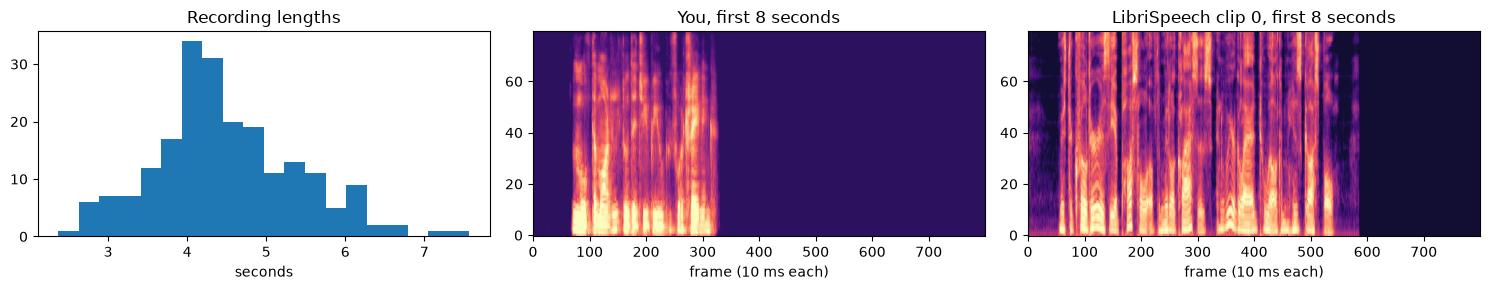

In [23]:
durations = [row["duration_s"] for row in rows]
print(f"{len(rows)} recordings, {sum(durations) / 60:.1f} minutes in total, "
      f"shortest {min(durations):.1f} s, longest {max(durations):.1f} s")

mine = read_wav(rows[0]["path"])
libri_audio, _ = load_librispeech()[0]

fig, axes = plt.subplots(1, 3, figsize=(15, 3))
axes[0].hist(durations, bins=20)
axes[0].set_xlabel("seconds")
axes[0].set_title("Recording lengths")
for ax, (title, audio) in zip(axes[1:], [("You", mine), ("LibriSpeech clip 0", libri_audio)]):
    features = processor.feature_extractor(audio, sampling_rate=SAMPLE_RATE, return_tensors="np").input_features[0]
    ax.imshow(features[:, :800], origin="lower", aspect="auto", cmap="magma", vmin=-1, vmax=1)
    ax.set_title(f"{title}, first 8 seconds")
    ax.set_xlabel("frame (10 ms each)")
plt.tight_layout()
plt.show()

## Part 4: training, validation, and test sets

### Why three sets

- The **training set** is what the model learns from.
- The **validation set** is what *you* learn from. In notebooks 03 and 04, you'll use it to make decisions: which learning rate, how many epochs, LoRA or full fine-tuning.
- The **test set** stays locked away until the very end. You evaluate on it once, with your final choices, and that's the number you report.

Why not make those decisions on the test set? Because every decision you make by looking at test scores fits your choices a little to those particular sentences. If you try ten learning rates and keep the one with the best test score, part of that score is luck, so it overstates how well the model will do on sentences it has never seen. It's like practice exams and the real exam: you can take practice exams as often as you like, but if you study the real exam's questions, your grade stops meaning anything.

### Why split by sentence, not by recording

If you record a sentence twice (with `--take 2`), both takes must land in the same set. Suppose take 1 is in training and take 2 is in test: the model has already trained on that exact sentence, so the test sentence isn't new, and the test score looks better than it should. This is called **leakage**: information from the test set leaking into training.

The fix is to split the **sentence ids**, and then send every recording to the set its sentence belongs to. Your key terms will still appear in both training and test sentences, and that's intended: it's the real situation, where the model learns a word from some sentences and has to recognize it in new ones.

### Sizes

With about 200 sentences: 70% training (about 146 sentences), 10% validation (about 21), and 20% test (about 42). The test set is bigger than the validation set because it produces the number you report, so it needs to be the more reliable one.

### TODO(you): write `split_by_sentence(rows, val_fraction, test_fraction, seed)`

**Inputs:**
- `rows`: a list of dicts (recordings), each with a `"sentence_id"` (`str`). Several rows can share a sentence id.
- `val_fraction`, `test_fraction`: floats, such as `0.1` and `0.2`.
- `seed`: an `int` that makes the shuffle repeatable.

**Output:** a **dict** with exactly three keys, `"train"`, `"val"`, and `"test"`. Each value is a **list of rows** (the same dicts you were given). Every row must end up in exactly one list, and all rows with the same sentence id must end up in the same list.

**Functions you'll use:**

- `{row["sentence_id"] for row in rows}` is a **set comprehension**. It builds a set, so duplicate ids disappear.
- `sorted(...)` returns a new sorted **list**. Sort the unique ids before shuffling: a set has no fixed order, so without sorting, the same seed could produce a different split.
- `rng = random.Random(seed)` creates a random number generator with its own seed. `rng.shuffle(ids)` shuffles the list **in place** and returns `None`, so write `rng.shuffle(ids)` on its own line, not `ids = rng.shuffle(ids)`.
- `round(x)` rounds a float to the nearest `int`.
- Slicing: `ids[:5]` is the first five items, `ids[5:8]` the next three, and `ids[8:]` everything after that.

**Steps:**
1. Get the unique sentence ids, sorted.
2. Shuffle them with `random.Random(seed)`.
3. Work out how many ids go to test (`round(len(ids) * test_fraction)`) and how many to validation, and slice the shuffled list into three parts: test first, then validation, then the rest for training.
4. Turn each part into a `set`, so checking whether an id belongs to it is fast.
5. Start with `{"train": [], "val": [], "test": []}`, go through the rows, and append each row to the list for its sentence's set.

In [33]:
# TODO(you): split the recordings into train/val/test by sentence id.
def split_by_sentence(rows, val_fraction=0.1, test_fraction=0.2, seed=0):
    ids = sorted({row["sentence_id"] for row in rows})
    rng = random.Random(seed)
    rng.shuffle(ids)
    n_test = round(len(ids) * test_fraction)
    n_val = round(len(ids) * val_fraction)
    test_ids = ids[:n_test]
    val_ids = ids[n_test:(n_val+n_test)]
    train_ids = ids[n_val+n_test:]
    test_set = set(test_ids)
    train_set = set(train_ids)
    val_set = set(val_ids)
    splits = { "train": [], "val": [], "test": []}
    for row in rows: 
        if row["sentence_id"] in test_set:
            splits["test"].append(row)
        elif row["sentence_id"] in train_set:
            splits["train"].append(row)
        else:
            splits["val"].append(row)
    return splits

The check makes 50 fake sentences with 1 to 3 takes each, splits them, and checks the rules: every row lands in exactly one set, no sentence appears in two sets, the sizes are right, and the same seed gives the same split. `a & b` is the intersection of two sets: the items in both.

In [34]:
fake_rows = [{"sentence_id": f"f{i:02d}", "take": take} for i in range(50) for take in range(1, 2 + i % 3)]
fake_splits = split_by_sentence(fake_rows, val_fraction=0.1, test_fraction=0.2, seed=0)

assert isinstance(fake_splits, dict) and set(fake_splits) == {"train", "val", "test"}, \
    "return a dict with the keys 'train', 'val', and 'test'"
assert sum(len(part) for part in fake_splits.values()) == len(fake_rows), "every row must land in exactly one split"
ids_in = {name: {row["sentence_id"] for row in part} for name, part in fake_splits.items()}
assert not (ids_in["train"] & ids_in["val"] or ids_in["train"] & ids_in["test"] or ids_in["val"] & ids_in["test"]), \
    "a sentence appears in two splits: all takes of a sentence must stay together"
assert len(ids_in["test"]) == 10 and len(ids_in["val"]) == 5, \
    f"with 50 sentences, expected 10 test and 5 validation sentences, got {len(ids_in['test'])} and {len(ids_in['val'])}"
assert split_by_sentence(fake_rows, 0.1, 0.2, seed=0) == fake_splits, "the same seed must give the same split"
assert split_by_sentence(fake_rows, 0.1, 0.2, seed=1) != fake_splits, "a different seed should give a different split"
print("Correct.")

Correct.


Now split your real recordings and save the result to `data/splits.json`, so every later notebook uses exactly the same split. It stores sentence ids, not recordings, so a second take you record later automatically joins its sentence's set.

- `{"seed": 0, **split_ids}` builds a new dict: the `seed` key plus every key and value of `split_ids`. The `**` unpacks a dict inside another.
- `save_json(obj, path)` writes a dict or list to a JSON file, a text format for nested data.

In [35]:
splits = split_by_sentence(rows, val_fraction=0.1, test_fraction=0.2, seed=0)
split_ids = {name: sorted({row["sentence_id"] for row in part}) for name, part in splits.items()}
save_json({"seed": 0, **split_ids}, DATA_DIR / "splits.json")

for name, part in splits.items():
    minutes = sum(row["duration_s"] for row in part) / 60
    categories = dict(Counter(row["category"] for row in part))
    print(f"{name:>5}: {len(split_ids[name]):3} sentences, {len(part):3} recordings, {minutes:4.1f} min, {categories}")

train: 146 sentences, 146 recordings, 10.9 min, {'ml': 60, 'everyday': 32, 'names': 21, 'tools': 33}
  val:  21 sentences,  21 recordings,  1.5 min, {'everyday': 4, 'ml': 9, 'names': 1, 'tools': 7}
 test:  42 sentences,  42 recordings,  3.2 min, {'ml': 20, 'everyday': 9, 'names': 4, 'tools': 9}


### Which terms can fine-tuning learn?

Fine-tuning can only learn a term from training sentences. Terms that appear in test sentences but in **no** training sentence make a natural experiment. If the model gets better at them anyway, it learned something general, like your voice or your microphone. If it only gets better at the terms it trained on, it learned the words themselves. Notebook 04 compares the two groups.

`any(...)` returns `True` if at least one value is true: `any(contains_term(text, term) for text in test_texts)` asks "does any test sentence contain this term?"

In [36]:
train_texts = {row["text"] for row in splits["train"]}
test_texts = {row["text"] for row in splits["test"]}

seen, unseen = [], []
for term in vocabulary:
    in_test = any(contains_term(text, term) for text in test_texts)
    in_train = any(contains_term(text, term) for text in train_texts)
    if in_test and in_train:
        seen.append(term)
    elif in_test:
        unseen.append(term)

print(f"{len(seen)} terms appear in test sentences and in training sentences.")
print(f"{len(unseen)} appear in test sentences only:", unseen)

29 terms appear in test sentences and in training sentences.
3 appear in test sentences only: ['PowerShell', 'epoch', 'cross-entropy']


## Part 5: the baseline

The **baseline** is how well Whisper does on your test sentences before any fine-tuning. Everything later is compared against it, so measure it exactly the way you'll measure the fine-tuned model: same test sentences, same normalization, same code.

You'll measure two models. whisper-tiny.en is the one you'll fine-tune. whisper-base.en is twice its size. If fine-tuned tiny ends up beating untuned base, you got better accuracy *and* a faster model.

### The pipeline, with types

It's the same pipeline as in notebook 01, starting from your WAV files:

| step | function | input | output |
|---|---|---|---|
| read audio | `read_wav(path)` | `str` path | `np.ndarray`, float32, shape `(n_samples,)` |
| features | `processor.feature_extractor(audios, sampling_rate=SAMPLE_RATE, return_tensors="pt")` | a list of waveforms | a `BatchFeature` (dict-like); its `.input_features` is a `torch.Tensor`, float32, shape `(batch, 80, 3000)` |
| generate | `model.generate(features)`, inside `with torch.no_grad():` | that tensor | a `torch.Tensor` of token ids, int64, shape `(batch, tokens)` |
| decode | `processor.batch_decode(ids, skip_special_tokens=True)` | that tensor | a list of str, one per clip |
| score | `jiwer.wer(references, hypotheses)` | two lists of str | a `float` |

`torch.no_grad()` tells PyTorch not to keep track of gradients, since you're only measuring. It makes generation faster and uses less memory.

The strings from `batch_decode` start with a space, because Whisper's tokens carry their leading space (the `Ġ` from notebook 01). `.strip()` removes it if you want tidy output; the normalizer ignores it either way.

### TODO(you): `transcribe` and `corpus_wer`

Write two functions. You'll reuse both in notebooks 03 and 04, so they're general: they take any list of waveforms, not file paths.

**`transcribe(model, audios, batch_size=8)`**
- `model`: a `WhisperForConditionalGeneration`.
- `audios`: a list of waveforms (1-D float32 NumPy arrays).
- Returns: a **list of str**, one transcript per waveform, in the same order.
- Steps: loop over the start positions `range(0, len(audios), batch_size)`, which gives 0, 8, 16, and so on. Take the slice `audios[start:start + batch_size]`; slicing past the end is fine in Python, it just stops at the last item. Run features, generate, and decode on that slice, and add the strings to a results list with `results.extend(strings)`. (`extend` adds every item of a list; `append` would add the whole list as one item.) It's your batching code from notebook 01, with slicing.

**`corpus_wer(references, hypotheses)`**
- Two lists of str of the same length.
- Returns: a `float`, the corpus-level WER after normalizing **every** string with `processor.tokenizer.normalize`.
- Steps: normalize both lists with list comprehensions, then pass the two normalized lists to `jiwer.wer`. Given lists, `jiwer.wer` computes the corpus WER: total errors divided by total reference words.

In [42]:
# TODO(you): transcribe a list of waveforms in batches; return a list of str.
def transcribe(model, audios, batch_size=8):
    results = []
    for start in range(0, len(audios), batch_size):
        batch = audios[start:start+batch_size]
        inputs = processor.feature_extractor(batch, sampling_rate = 16000, return_tensors="pt")
        with torch.no_grad():
            predicted_ids = model.generate(inputs.input_features)
        decoded_strings = processor.batch_decode(predicted_ids, skip_special_tokens = True)
        results.extend(decoded_strings)
    return results

# TODO(you): corpus-level WER after normalizing both lists.
def corpus_wer(references, hypotheses):
    corpus_wer = jiwer.wer(
        [processor.tokenizer.normalize(r) for r in references],
        [processor.tokenizer.normalize(h) for h in hypotheses],
    )
    return corpus_wer

In [43]:
assert corpus_wer(["Mr. Quilter is here."], ["mister quilter is here"]) == 0.0, "normalize both lists before scoring"
assert abs(corpus_wer(["a b c d", "e f"], ["a x c", "e f"]) - 2 / 6) < 1e-9, \
    "corpus WER is total errors / total reference words: here 2 errors over 6 words"

model = WhisperForConditionalGeneration.from_pretrained("openai/whisper-tiny.en").eval()
sample_rows = rows[:3]
sample_hyps = transcribe(model, [read_wav(row["path"]) for row in sample_rows], batch_size=2)
assert isinstance(sample_hyps, list) and len(sample_hyps) == 3, "return one transcript per waveform"
assert all(isinstance(h, str) for h in sample_hyps), "each transcript should be a str"
for row, hyp in zip(sample_rows, sample_hyps):
    print(f"reference:  {row['text']}\nhypothesis: {hyp.strip()}\n")
print("Correct.")

reference:  Move the model to the GPU before training.
hypothesis: Move the model to the GPU before training.

reference:  I can't make it tonight, but let's catch up this weekend.
hypothesis: I can't make it tonight, but let's catch up this weekend.

reference:  Honestly, I think the second option makes more sense.
hypothesis: Honestly, I think the second option makes more sense.

Correct.


### TODO(you): measure both models on the test set

Use your two functions to compute the test WER of whisper-tiny.en and whisper-base.en. Keep the transcripts too, because the analysis after this needs them.

1. Get the test rows (`splits["test"]`), their references (each row's `"text"`), and their audio (`read_wav(row["path"])` for each row).
2. For each model name in `["openai/whisper-tiny.en", "openai/whisper-base.en"]`: load the model with `WhisperForConditionalGeneration.from_pretrained(name).eval()`, transcribe the test audio, and compute the WER.
3. Store the results in a dict called `baseline` that maps each model name to another dict, `{"wer": <float>, "hypotheses": <list of str>}`. A dict inside a dict is fine: `baseline["openai/whisper-tiny.en"]["wer"]` reads the WER back.

This takes about a minute; base.en is about twice as slow as tiny.en.

In [44]:
test_rows = splits["test"]
model_names = ["openai/whisper-tiny.en", "openai/whisper-base.en"]
# TODO(you): baseline WER of tiny.en and base.en on the test set.
test_refs = [row["text"] for row in test_rows]
test_audios = [read_wav(row["path"]) for row in test_rows]
baseline = {}
for name in model_names:
    model = WhisperForConditionalGeneration.from_pretrained(name).eval()
    hyps = transcribe(model, test_audios)
    wer = corpus_wer(test_refs, hyps)
    baseline[name] = {"wer": wer, "hypotheses": hyps}


for name, result in baseline.items():
    print(f"{name}: test WER {result['wer']:.1%}")

openai/whisper-tiny.en: test WER 31.4%
openai/whisper-base.en: test WER 25.6%


In [45]:
assert set(baseline) == {"openai/whisper-tiny.en", "openai/whisper-base.en"}, "one entry per model name"
for name, result in baseline.items():
    assert len(result["hypotheses"]) == len(test_rows), f"{name}: one hypothesis per test recording"
    assert abs(result["wer"] - corpus_wer(test_refs, result["hypotheses"])) < 1e-9, f"{name}: WER doesn't match the hypotheses"
print("Correct.")

Correct.


### TODO(you): where does it go wrong?

A single WER hides where the errors are. Break down whisper-tiny.en's test errors two ways.

**1. WER per category.** Build a dict, `category_wer`, that maps each category to the corpus WER of only the test recordings in that category.
- `zip(test_rows, tiny_hyps)` walks through the rows and the hypotheses in pairs: `for row, hyp in zip(test_rows, tiny_hyps):`.
- Group first, then score: collect each category's references and hypotheses (for example, in two dicts of lists), then call `corpus_wer` once per category.
- `d.setdefault(key, [])` returns `d[key]` if it exists; otherwise it stores an empty list under `key` and returns that. So `refs_by_category.setdefault(category, []).append(text)` adds `text` to the category's list, creating the list the first time.

**2. Term recall: how often do your key terms come out right?** Write `term_recall(references, hypotheses, terms)`:
- Inputs: two lists of str of the same length, and a list of terms.
- For every pair (reference, hypothesis), and every term that appears in the **reference** (use `contains_term`), count one occurrence. If the term also appears in the **hypothesis**, it's a hit. Otherwise, record a miss as a tuple: `(term, reference, hypothesis)`.
- Return a **dict**: `{"hits": int, "total": int, "recall": float, "misses": list of tuples}`, where `"recall"` is `hits / total`. If `total` is 0, set `"recall"` to `None` instead, because dividing by zero raises an error.

Recall is the fraction of term occurrences the model got right. WER treats "the" and "LoRA" the same; term recall looks only at the words fine-tuning is meant to fix, so it's often the clearest number in the final story.

In [48]:
# TODO(you): count term hits and misses.
def term_recall(references, hypotheses, terms):
    for row, hyp in zip(test_rows, tiny_hyps):
        hits = 0
        total = 0
        misses = []
        for ref, hyp in zip(references, hypotheses):
            for term in terms:
                if contains_term(ref, term):
                    total+=1 
                    if contains_term(hyp, term):
                        hits +=1 
                    else:
                        misses.append((term, ref, hyp))
        recall = hits / total if total > 0 else None
    return {"hits": hits, "total": total, "recall": recall, "misses": misses}

tiny_hyps = baseline["openai/whisper-tiny.en"]["hypotheses"]

refs_by_category = {}
hyps_by_category = {}
for row, hyp in zip(test_rows, tiny_hyps):
    cat = row["category"]
    refs_by_category.setdefault(cat,[]).append(row["text"])
    hyps_by_category.setdefault(cat, []).append(hyp)
        
# TODO(you): the WER of each category, as a dict {category: wer}.
category_wer = {
    cat: corpus_wer(refs_by_category[cat], hyps_by_category[cat])
    for cat in refs_by_category
}

tiny_terms = term_recall(test_refs, tiny_hyps, vocabulary)

print("WER per category:", {category: f"{wer:.1%}" for category, wer in category_wer.items()})
print(f"Term recall: {tiny_terms['hits']}/{tiny_terms['total']} = {tiny_terms['recall']:.0%}")

WER per category: {'ml': '38.4%', 'everyday': '14.1%', 'names': '35.3%', 'tools': '31.9%'}
Term recall: 14/45 = 31%


In [49]:
fake = term_recall(
    ["We used LoRA on the GPU.", "No terms here.", "LoRA again."],
    ["We used Laura on the GPU.", "No terms here.", "LoRA again."],
    ["LoRA", "GPU"],
)
assert isinstance(fake, dict) and set(fake) == {"hits", "total", "recall", "misses"}
assert fake["hits"] == 2 and fake["total"] == 3, f"expected 2 hits out of 3, got {fake['hits']} out of {fake['total']}"
assert abs(fake["recall"] - 2 / 3) < 1e-9
assert fake["misses"] == [("LoRA", "We used LoRA on the GPU.", "We used Laura on the GPU.")], f"got {fake['misses']}"
assert term_recall(["Nothing here."], ["Nothing here."], ["LoRA"])["recall"] is None, "recall should be None when no term occurs"
assert set(category_wer) == {row["category"] for row in test_rows}, "one WER per category that appears in the test set"
print("Correct.")

Correct.


### The worst sentences and the most-missed terms

`Counter(...).most_common(10)` lists the 10 most frequent values with their counts. `sorted(..., key=..., reverse=True)` sorts the (row, hypothesis) pairs by their WER, highest first; `key` is a function that computes the value to sort by, and `lambda pair: ...` defines a small function inline.

In [50]:
print("Most-missed terms:", Counter(term for term, _, _ in tiny_terms["misses"]).most_common(10))
print()
scored = sorted(zip(test_rows, tiny_hyps), key=lambda pair: corpus_wer([pair[0]["text"]], [pair[1]]), reverse=True)
for row, hyp in scored[:8]:
    print(f"{corpus_wer([row['text']], [hyp]):5.0%}  reference:  {row['text']}")
    print(f"       hypothesis: {hyp.strip()}")

Most-missed terms: [('Whisper', 2), ('Yash', 2), ('logits', 2), ('faster-whisper', 2), ('AdamW', 1), ('epoch', 1), ('Udita', 1), ('cross-entropy', 1), ('WER', 1), ('LibriSpeech', 1)]

 117%  reference:  Softmax turns the logits into probabilities.
       hypothesis: So, it lacks the largest and improbable links.
  88%  reference:  Each user could have their own LoRA adapter.
       hypothesis: B2's could have their own, you know, adapt motion.
  82%  reference:  My default Python is too new for some of these libraries.
       hypothesis: My day for life honest to a new person called these libraries.
  75%  reference:  Yash and Udita are coming to the party.
       hypothesis: Ya Shinobi Darker into the party.
  75%  reference:  I found a bug in my data collator.
       hypothesis: found for GIMA data coolators.
  62%  reference:  The LLM rewrites my dictation into clean text.
       hypothesis: The LLM writes magic patient and to clean text.
  57%  reference:  Backpropagation uses the 

Save the baseline to `results/baseline.json`. Notebook 04 compares the fine-tuned model against these exact transcripts, so the transcripts are saved too, keyed by file name.

In [51]:
save_json(
    {
        "test_wer": {name: result["wer"] for name, result in baseline.items()},
        "tiny_category_wer": category_wer,
        "tiny_term_recall": {key: value for key, value in tiny_terms.items() if key != "misses"},
        "tiny_test_hypotheses": {row["file"]: hyp for row, hyp in zip(test_rows, tiny_hyps)},
    },
    RESULTS_DIR / "baseline.json",
)
print("Saved", RESULTS_DIR / "baseline.json")

Saved C:\Users\praja\Desktop\yp\Whisper\whisper-finetune\results\baseline.json


## Part 6: move your functions into `whisper_ft.py`

Notebooks 03 and 04 need `transcribe`, `corpus_wer`, and `term_recall`. Instead of copying them into every notebook, put them in `whisper_ft.py`, the shared file, and import them from there. Real ML projects are organized this way: you explore in notebooks and keep reusable code in modules (a **module** is just a `.py` file you can import).

### TODO(you)

1. Open `whisper_ft.py` and scroll to the bottom, to the "Your code" section.
2. Replace the three stubs under "From notebook 02" (the functions whose body only raises `NotImplementedError`) with your versions from this notebook. Copy each whole function, from `def` to its last line.
3. Save the file and run the check below. Autoreload picks up the change without a restart.

Your functions can use `processor`, `SAMPLE_RATE`, `contains_term`, `jiwer`, `torch`, and `np` there too: `whisper_ft.py` already defines or imports all of them.

In [52]:
import whisper_ft

check_rows = rows[:4]
check_audios = [read_wav(row["path"]) for row in check_rows]
check_refs = [row["text"] for row in check_rows]
check_hyps = whisper_ft.transcribe(model, check_audios, batch_size=3)
assert check_hyps == transcribe(model, check_audios, batch_size=3), "whisper_ft.transcribe gives different output"
assert whisper_ft.corpus_wer(check_refs, check_hyps) == corpus_wer(check_refs, check_hyps)
assert whisper_ft.term_recall(check_refs, check_hyps, vocabulary) == term_recall(check_refs, check_hyps, vocabulary)
print("Correct. Notebooks 03 and 04 can import them now.")

NameError: name 'test_rows' is not defined

## What's next

You now have your own dataset, a fixed split, and a baseline. In notebook 03 you'll fine-tune whisper-tiny.en on the training set while watching the validation WER.

Commit your work; the recordings stay out of git automatically:

    git add -A
    git commit -m "Notebook 02: my dataset and baseline"
    git push

### Check your understanding

1. Why do you need a validation set when you already have a test set?
2. You record every sentence twice, then split by *recording* instead of by sentence. What goes wrong? Would the test WER come out too high or too low?
3. Some terms appear only in test sentences. What do you expect fine-tuning to do for them, and why is that worth measuring?
4. Your test set has about 42 sentences of about 9 words each. If one more word comes out wrong, how much does the WER change? What does that tell you about a model that wins by half a percentage point?
5. Next month you record 50 more sentences. How would you add them without changing which set the old sentences are in? (Hint: what if each sentence's set depended only on its own id?)
6. Compare tiny.en's WER on your voice with its 9.0% on LibriSpeech. What could explain the difference?